## Importation des librairy

Importer toutes les bibliothèques nécessaires pour le traitement d’images, le deep learning, la validation croisée, et l’affichage des métriques.

In [1]:
import os
import glob
import numpy as np
import cv2
import glob
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras.applications import (
    ResNet50,
    VGG19,
    EfficientNetB0,
    DenseNet121,
    MobileNetV2
)
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score
from keras.preprocessing import image
from tensorflow.keras import backend as K
import gc
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import tensorflow as tf
tf.get_logger().setLevel('ERROR')


## Chargement des images

In [2]:

BASE_PATH = r"F:/Memoire AI/DATA/**/*.png"
ALL_IMAGES = glob.glob(BASE_PATH, recursive=True)

N_BC = [img for img in ALL_IMAGES if os.path.basename(os.path.dirname(img)) == "0"]
Y_BC = [img for img in ALL_IMAGES if os.path.basename(os.path.dirname(img)) == "1"]

print("Toatl images :", len(ALL_IMAGES))
print("Images non-cancer :", len(N_BC))
print("Images cancer     :", len(Y_BC))


Toatl images : 2107
Images non-cancer : 2010
Images cancer     : 97


## Visualisation de quelques images

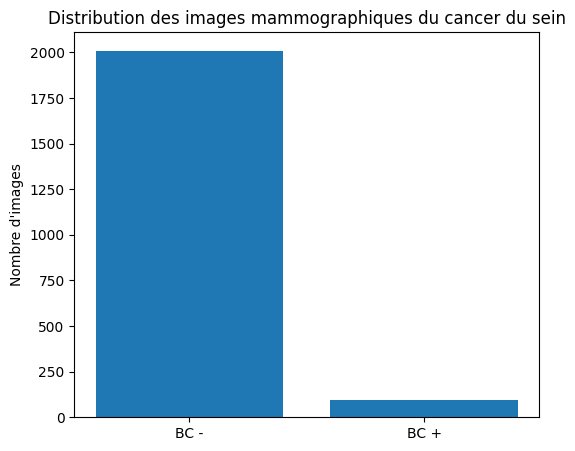

In [3]:
import matplotlib.pyplot as plt

counts = [len(N_BC), len(Y_BC)]
labels = ['BC -', 'BC +']

plt.figure(figsize=(6, 5))
plt.bar(labels, counts)
plt.ylabel('Nombre d\'images')
plt.title('Distribution des images mammographiques du cancer du sein')
plt.show()

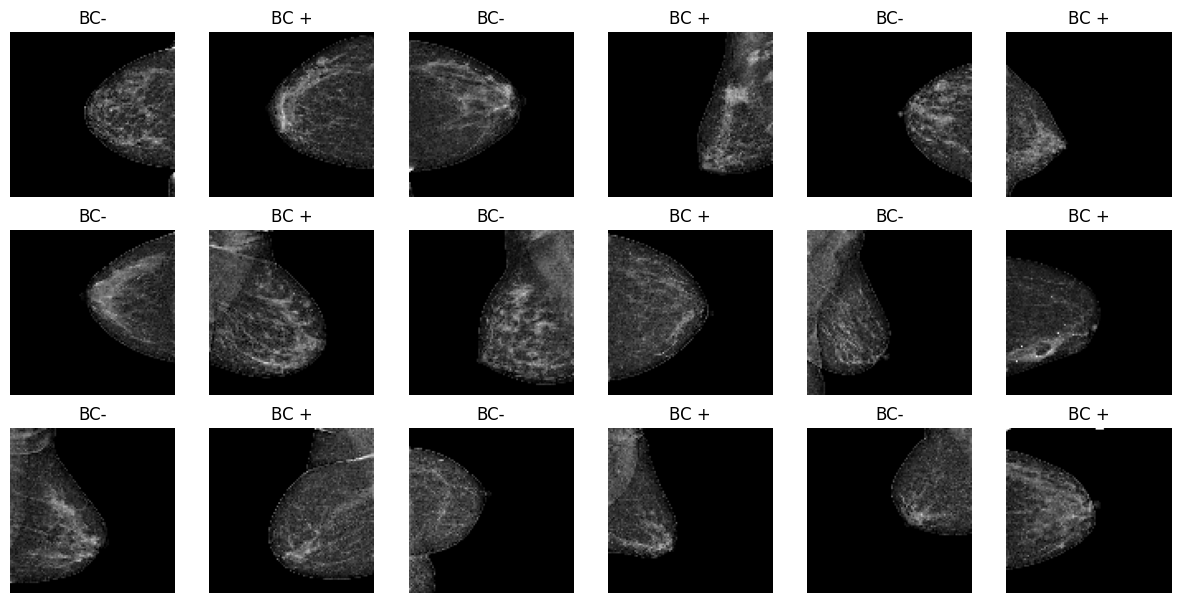

In [4]:
# Tirage aléatoire des images pour affichage
num_samples = 9
indices_non_cancer = np.random.choice(len(N_BC), size=min(len(N_BC), num_samples), replace=False)
indices_cancer = np.random.choice(len(Y_BC), size=min(len(Y_BC), num_samples), replace=False)

plt.figure(figsize=(15, 15))

# Affichage des images sans cancer
for i, idx in enumerate(indices_non_cancer):
    img = image.load_img(N_BC[idx], target_size=(100, 100))
    img = image.img_to_array(img)
    plt.subplot(6, 6, 2*i + 1)
    plt.axis('off')
    plt.title('BC-')
    plt.imshow(img.astype('uint8'))

# Affichage des images avec cancer
for i, idx in enumerate(indices_cancer):
    img = image.load_img(Y_BC[idx], target_size=(100, 100))
    img = image.img_to_array(img)
    plt.subplot(6, 6, 2*i + 2)
    plt.axis('off')
    plt.title('BC +')
    plt.imshow(img.astype('uint8'))

plt.show()

## Prétraitement des images

Convertir les images en format standard (128×128, 3 canaux).

Appliquer un CLAHE pour améliorer le contraste.

Préparer le tableau X pour les images et y pour les labels.

In [5]:
IMG_SIZE = 128

def preprocess(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    h, w = img.shape
    img = img[10:h-10, 10:w-10]
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    clahe = cv2.createCLAHE(clipLimit=2.0)
    img = clahe.apply(img)
    img = img.astype("float32") / 255.0
    img = np.stack((img,)*3, axis=-1)
    return img

X = np.array([preprocess(p) for p in N_BC + Y_BC])
y = np.array([0] * len(N_BC) + [1] * len(Y_BC))

print("Dataset final :", X.shape, y.shape)


Dataset final : (2107, 128, 128, 3) (2107,)


## Oversampling pour équilibrer les classes

Équilibrer la classe minoritaire  en générant des images synthétiques via augmentation. X_bal et y_bal sont le dataset final pour l’entraînement.

In [6]:
X_pos = X[y == 1]
y_pos = y[y == 1]

augmenter = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
)

aug_images = []
aug_labels = []

TARGET = len(N_BC)  #  équilibrer positifs et négatifs

for i in range(TARGET - len(X_pos)):
    idx = np.random.randint(0, len(X_pos))
    img = X_pos[idx].reshape((1, IMG_SIZE, IMG_SIZE, 3))
    batch = next(augmenter.flow(img, batch_size=1))
    aug_images.append(batch[0])
    aug_labels.append(1)

aug_images = np.array(aug_images)
aug_labels = np.array(aug_labels)

X_bal = np.concatenate([X, aug_images])
y_bal = np.concatenate([y, aug_labels])
X_bal, y_bal = shuffle(X_bal, y_bal, random_state=42)

print("Après oversampling :", X_bal.shape, y_bal.shape)


Après oversampling : (4020, 128, 128, 3) (4020,)


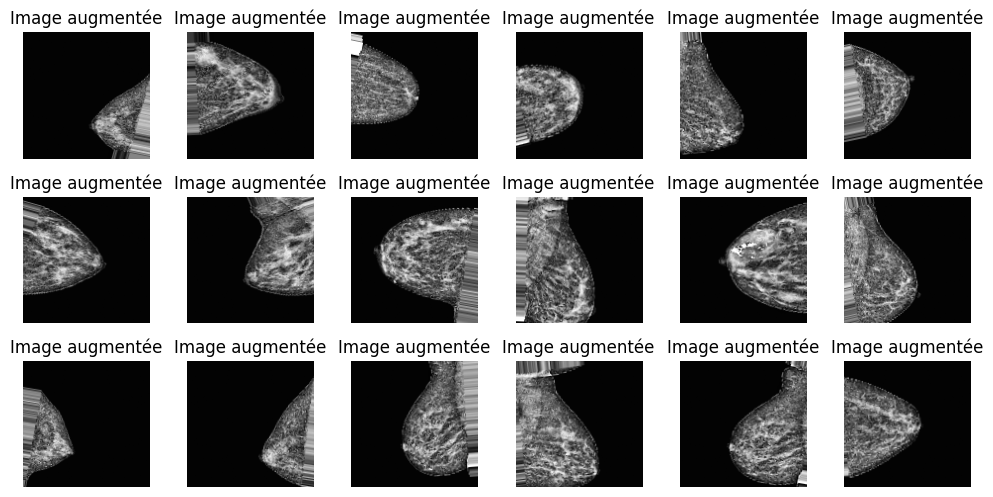

In [7]:
import matplotlib.pyplot as plt

# Nombre d’images à afficher
N = 18
plt.figure(figsize=(10, 10))

for i in range(N):
    plt.subplot(6, 6, i+1)
    plt.imshow(aug_images[i])   # les images sont déjà au format RGB (3 canaux)
    plt.axis("off")
    plt.title("Image augmentée")

plt.tight_layout()
plt.show()


## Visualisation des classes après oversampling

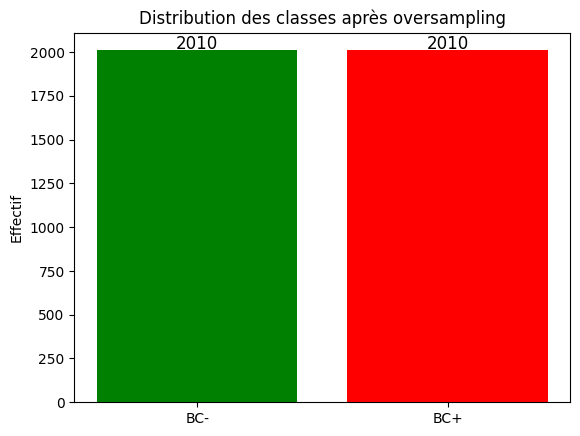

In [8]:
labels = ["BC-", "BC+"]
unique_bal, counts_bal = np.unique(y_bal, return_counts=True)

colors = ["green", "red"]  # BC- = vert, BC+ = rouge

plt.bar(labels, counts_bal, color=colors)
plt.ylabel("Effectif")
plt.title("Distribution des classes après oversampling")

# === Ajout des étiquettes ===
for i, v in enumerate(counts_bal):
    plt.text(i, v + 10, str(v), ha='center', fontsize=12)

plt.show()


## Définition de  la fonction Focal Loss adaptée aux classes déséquilibrées

In [ ]:
#def focal_loss(gamma=2., alpha=.25):
    #def loss(y_true, y_pred):
      #  y_true = tf.cast(y_true, tf.float32)
      #  bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
       # p_t = y_true * y_pred + (1-y_true) * (1-y_pred)
       # fl = alpha * tf.pow((1-p_t), gamma) * bce
        #return tf.reduce_mean(fl)
   # return loss


## Définition de  la fonction qui rregroupera nos 5 modèles

finetuning avec extraction des features car datset petit

In [9]:
def get_model(backbone_name):
    backbones = {
       # "resnet50": ResNet50,
       # "vgg19": VGG19,
       # "efficientnet": EfficientNetB0,
       # "densenet": DenseNet121,
        "mobilenet": MobileNetV2,
    }

    base = backbones[backbone_name](
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    base.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    x = Dropout(0.5)(x)
    out = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=base.input,outputs=out)
    model.compile(
        loss="binary_crossentropy",
        optimizer=Adam(1e-4),
        metrics=["accuracy", tf.keras.metrics.AUC(name="AUC")]
    )
    return model


# division des données en ensemble d'entrainement et de test

In [10]:
from sklearn.model_selection import train_test_split

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.2 , random_state=42)

print("Taille de données d'entrainement X:", X_train.shape)
print("Taille de données d'entrainement Y :", y_train.shape)
print("Taille de données de test X :", X_test.shape)
print("Taille de données de test Y :", y_test.shape)

Taille de données d'entrainement X: (3216, 128, 128, 3)
Taille de données d'entrainement Y : (3216,)
Taille de données de test X : (804, 128, 128, 3)
Taille de données de test Y : (804,)


## Entrainement par Validation croisé 

In [11]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K
import numpy as np
import gc

# ================================
# Création du dossier de sauvegarde
# ================================
os.makedirs("saved_models", exist_ok=True)

best_auc = 0
best_model_path = "saved_models/best_mobilenet_model.h5"

# ================================
# 5 — K-Fold (SUR X_train)
# ================================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#MODELS = ["resnet50", "vgg19", "efficientnet", "densenet", "mobilenet"]
MODELS = ["mobilenet"]

results = {}

for model_name in MODELS:
    print("\n\n### TRAINING :", model_name.upper())

    results[model_name] = {
        "history": [],
        "y_true": [],
        "y_prob": [],
        "auc": [],
        "accuracy": []
    }

    fold = 1
    for train_idx, val_idx in kf.split(X_train, y_train):
        print(f"\n===== Fold {fold} : {model_name} =====")

        X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
        y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

        model = get_model(model_name)

        callbacks = [
            EarlyStopping(monitor="val_AUC", patience=5, restore_best_weights=True),
            ReduceLROnPlateau(monitor="val_loss", patience=3)
        ]

        history = model.fit(
            X_train_fold, y_train_fold,
            validation_data=(X_val_fold, y_val_fold),
            epochs=20,
            batch_size=16,
            callbacks=callbacks,
            verbose=1
        )
        

        # ================================
        # Prédictions
        # ================================
        y_prob = model.predict(X_val_fold).reshape(-1)
        y_pred = (y_prob > 0.5).astype(int)

        # ================================
        # Stockage métriques
        # ================================
        results[model_name]["history"].append(history.history)
        results[model_name]["y_true"].append(y_val_fold)
        results[model_name]["y_prob"].append(y_prob)

        auc = roc_auc_score(y_val_fold, y_prob)
        acc = np.mean(y_pred == y_val_fold)

        results[model_name]["auc"].append(auc)
        results[model_name]["accuracy"].append(acc)
        
        # ================================
        # Sauvegarde du meilleur modèle
        # ================================
        if auc > best_auc:
            best_auc = auc
            model.save(best_model_path)
            print(f"\n🔥 Nouveau meilleur modèle sauvegardé (AUC = {auc:.3f})")

        # ================================
        # Rapports
        # ================================
        print("Classification Report – Fold", fold)
        print(classification_report(
            y_val_fold, y_pred,
            target_names=["Cancer -", "Cancer +"]
        ))

        print("Confusion Matrix")
        print(confusion_matrix(y_val_fold, y_pred))

        print(f"AUC : {auc:.3f}")
        print(f"Accuracy : {acc:.3f}")

        fold += 1
        K.clear_session()
        gc.collect()
# ================================
# Résultats globaux
# ================================
print("\n================================")
print("RÉSULTATS GLOBAUX")
print("================================")

mean_auc = np.mean(results["mobilenet"]["auc"])
mean_acc = np.mean(results["mobilenet"]["accuracy"])

print(f"AUC moyen : {mean_auc:.3f}")
print(f"Accuracy moyenne : {mean_acc:.3f}")

print(f"\n✅ Meilleur modèle sauvegardé dans : {best_model_path}")
print(f"Meilleure AUC obtenue : {best_auc:.3f}")




### TRAINING : MOBILENET

===== Fold 1 : mobilenet =====
Epoch 1/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 39s 196ms/step - AUC: 0.5425 - accuracy: 0.5237 - loss: 0.8379 - val_AUC: 0.8296 - val_accuracy: 0.7376 - val_loss: 0.5471 - learning_rate: 1.0000e-04
Epoch 2/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 30s 186ms/step - AUC: 0.7842 - accuracy: 0.7103 - loss: 0.5609 - val_AUC: 0.9509 - val_accuracy: 0.8913 - val_loss: 0.3924 - learning_rate: 1.0000e-04
Epoch 3/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 41s 256ms/step - AUC: 0.8773 - accuracy: 0.7947 - loss: 0.4419 - val_AUC: 0.9696 - val_accuracy: 0.9301 - val_loss: 0.3106 - learning_rate: 1.0000e-04
Epoch 4/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 51s 316ms/step - AUC: 0.9268 - accuracy: 0.8550 - loss: 0.3592 - val_AUC: 0.9737 - val_accuracy: 0.9457 - val_loss: 0.2609 - learning_rate: 1.0000e-04
Epoch 5/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 41s 253ms/step - AUC: 0.9488 - accuracy: 0.8849 - loss: 0.3050 - val_AUC: 0.9751 - val_accuracy: 0.9534 - val_loss: 0.2317 - learning_rat

In [12]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model
from tensorflow.keras import backend as K
import numpy as np
import gc
import os

# ================================
# Dossier sauvegarde
# ================================
os.makedirs("saved_models", exist_ok=True)

# ================================
# K-FOLD
# ================================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {
    "history": [],
    "auc": [],
    "accuracy": []
}

best_auc = 0
best_model_path = "saved_models/best_mobilenet_model.h5"

fold = 1

for train_idx, val_idx in kf.split(X_train, y_train):

    print(f"\n==============================")
    print(f"FOLD {fold}")
    print(f"==============================")

    X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

    model = get_model("mobilenet")

    callbacks = [
        EarlyStopping(monitor="val_AUC", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", patience=3)
    ]

    history = model.fit(
        X_train_fold,
        y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=20,
        batch_size=16,
        callbacks=callbacks,
        verbose=1
    )

    # ================================
    # Prédictions
    # ================================
    y_prob = model.predict(X_val_fold).reshape(-1)
    y_pred = (y_prob > 0.5).astype(int)

    auc = roc_auc_score(y_val_fold, y_prob)
    acc = np.mean(y_pred == y_val_fold)

    results["auc"].append(auc)
    results["accuracy"].append(acc)
    results["history"].append(history.history)

    # ================================
    # Sauvegarde meilleur modèle
    # ================================
    if auc > best_auc:
        best_auc = auc
        model.save(best_model_path)
        print(f"🔥 Nouveau meilleur modèle sauvegardé (AUC = {auc:.3f})")

    # ================================
    # Rapports
    # ================================
    print("\nClassification Report")
    print(classification_report(
        y_val_fold,
        y_pred,
        target_names=["Cancer -", "Cancer +"]
    ))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_val_fold, y_pred))

    print(f"AUC : {auc:.3f}")
    print(f"Accuracy : {acc:.3f}")

    fold += 1

    K.clear_session()
    gc.collect()

# ================================
# Résultats K-Fold
# ================================
print("\n================================")
print("K-FOLD RESULTS")
print("================================")

mean_auc = np.mean(results["auc"])
std_auc = np.std(results["auc"])

mean_acc = np.mean(results["accuracy"])
std_acc = np.std(results["accuracy"])

print(f"AUC moyen : {mean_auc:.3f} ± {std_auc:.3f}")
print(f"Accuracy moyenne : {mean_acc:.3f} ± {std_acc:.3f}")

# ================================
# Réentraînement sur tout X_train
# ================================
print("\n================================")
print("TRAINING FINAL MODEL")
print("================================")

final_model = get_model("mobilenet")

callbacks = [
    EarlyStopping(monitor="val_AUC", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", patience=3)
]

history = final_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

# ================================
# Test final
# ================================
print("\n================================")
print("TEST SET EVALUATION")
print("================================")

y_prob_test = final_model.predict(X_test).reshape(-1)
y_pred_test = (y_prob_test > 0.5).astype(int)

auc_test = roc_auc_score(y_test, y_prob_test)
acc_test = np.mean(y_pred_test == y_test)

print("\nClassification Report (Test)")
print(classification_report(
    y_test,
    y_pred_test,
    target_names=["Cancer -", "Cancer +"]
))

print("\nConfusion Matrix (Test)")
print(confusion_matrix(y_test, y_pred_test))

print(f"\nTest AUC : {auc_test:.3f}")
print(f"Test Accuracy : {acc_test:.3f}")

# ================================
# Sauvegarde modèle final
# ================================
final_model.save("saved_models/final_mobilenet_model.h5")

print("\n✅ Final model saved : saved_models/final_mobilenet_model.h5")


FOLD 1
Epoch 1/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 55s 263ms/step - AUC: 0.5476 - accuracy: 0.5373 - loss: 0.8170 - val_AUC: 0.8558 - val_accuracy: 0.7640 - val_loss: 0.5457 - learning_rate: 1.0000e-04
Epoch 2/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 37s 231ms/step - AUC: 0.7678 - accuracy: 0.6944 - loss: 0.5801 - val_AUC: 0.9623 - val_accuracy: 0.9161 - val_loss: 0.3867 - learning_rate: 1.0000e-04
Epoch 3/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 36s 226ms/step - AUC: 0.8906 - accuracy: 0.8079 - loss: 0.4250 - val_AUC: 0.9726 - val_accuracy: 0.9457 - val_loss: 0.3049 - learning_rate: 1.0000e-04
Epoch 4/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 35s 218ms/step - AUC: 0.9270 - accuracy: 0.8495 - loss: 0.3599 - val_AUC: 0.9748 - val_accuracy: 0.9581 - val_loss: 0.2563 - learning_rate: 1.0000e-04
Epoch 5/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 36s 221ms/step - AUC: 0.9509 - accuracy: 0.8900 - loss: 0.3030 - val_AUC: 0.9757 - val_accuracy: 0.9596 - val_loss: 0.2260 - learning_rate: 1.0000e-04
Epoch 6/20
161/161 ━━━━━━━━━━━━━━━━━━

🔥 Nouveau meilleur modèle sauvegardé (AUC = 0.979)

Classification Report
              precision    recall  f1-score   support

    Cancer -       0.95      0.99      0.97       318
    Cancer +       0.99      0.94      0.97       326

    accuracy                           0.97       644
   macro avg       0.97      0.97      0.97       644
weighted avg       0.97      0.97      0.97       644


Confusion Matrix
[[314   4]
 [ 18 308]]
AUC : 0.979
Accuracy : 0.966

FOLD 2
Epoch 1/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 54s 275ms/step - AUC: 0.6597 - accuracy: 0.6121 - loss: 0.7098 - val_AUC: 0.9098 - val_accuracy: 0.8274 - val_loss: 0.4608 - learning_rate: 1.0000e-04
Epoch 2/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 41s 257ms/step - AUC: 0.8309 - accuracy: 0.7501 - loss: 0.5075 - val_AUC: 0.9621 - val_accuracy: 0.9191 - val_loss: 0.3425 - learning_rate: 1.0000e-04
Epoch 3/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 36s 223ms/step - AUC: 0.9040 - accuracy: 0.8255 - loss: 0.3992 - val_AUC: 0.9722 - val_accuracy: 0.

🔥 Nouveau meilleur modèle sauvegardé (AUC = 0.988)

Classification Report
              precision    recall  f1-score   support

    Cancer -       0.96      0.97      0.97       317
    Cancer +       0.97      0.96      0.97       326

    accuracy                           0.97       643
   macro avg       0.97      0.97      0.97       643
weighted avg       0.97      0.97      0.97       643


Confusion Matrix
[[307  10]
 [ 12 314]]
AUC : 0.988
Accuracy : 0.966

FOLD 5
Epoch 1/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 55s 285ms/step - AUC: 0.5985 - accuracy: 0.5593 - loss: 0.7889 - val_AUC: 0.8676 - val_accuracy: 0.7776 - val_loss: 0.5185 - learning_rate: 1.0000e-04
Epoch 2/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 35s 219ms/step - AUC: 0.7653 - accuracy: 0.7042 - loss: 0.5883 - val_AUC: 0.9654 - val_accuracy: 0.9051 - val_loss: 0.3634 - learning_rate: 1.0000e-04
Epoch 3/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 35s 217ms/step - AUC: 0.8772 - accuracy: 0.7967 - loss: 0.4431 - val_AUC: 0.9779 - val_accuracy: 0.


Classification Report (Test)
              precision    recall  f1-score   support

    Cancer -       0.94      0.96      0.95       422
    Cancer +       0.95      0.94      0.95       382

    accuracy                           0.95       804
   macro avg       0.95      0.95      0.95       804
weighted avg       0.95      0.95      0.95       804


Confusion Matrix (Test)
[[405  17]
 [ 24 358]]

Test AUC : 0.975
Test Accuracy : 0.949

✅ Final model saved : saved_models/final_mobilenet_model.h5


## Visualtion par fold et par modèle

In [13]:
import matplotlib.pyplot as plt

# Graduations voulues
xticks = [0, 4, 8, 12, 16, 20]

for model_name in MODELS:
    print(f"\n===== PLOTS FOR MODEL: {model_name.upper()} =====")

    for fold_idx, history in enumerate(results[model_name]["history"]):

        fold_num = fold_idx + 1
        epochs = range(1, len(history.get('loss', [])) + 1)

        # =====================
        # LOSS — 1 figure par fold
        # =====================
        plt.figure(figsize=(6,4))
        plt.plot(epochs, history.get('loss', []), label='Train Loss')
        plt.plot(epochs, history.get('val_loss', []), label='Validation Loss')
        plt.title(f'{model_name.upper()} - Fold {fold_num} - Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')

        plt.xlim(0, 21)                  # origine à 0
        plt.xticks(xticks)               # graduations personnalisées

        #plt.legend()
        plt.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),
        ncol=3,
        fontsize=9
            )
        plt.show()

        # =====================
        # AUC — 1 figure par fold
        # =====================
        train_auc = history.get('AUC', history.get('auc', []))
        val_auc   = history.get('val_AUC', history.get('val_auc', []))

        plt.figure(figsize=(6,4))
        plt.plot(epochs, train_auc, label='Train AUC')
        plt.plot(epochs, val_auc, label='Validation AUC')
        plt.title(f'{model_name.upper()} - Fold {fold_num} - AUC')
        plt.xlabel('Epoch')
        plt.ylabel('AUC')

        plt.xlim(0, 21)                  # origine à 0
        plt.xticks(xticks)               # graduations personnalisées

       # plt.legend()
        plt.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),
        ncol=3,
        fontsize=9
            )
        plt.show()



===== PLOTS FOR MODEL: MOBILENET =====


KeyError: 'mobilenet'

### Visualiation de tous les folds sur un modèle


===== PLOTS FOR MODEL: MOBILENET =====


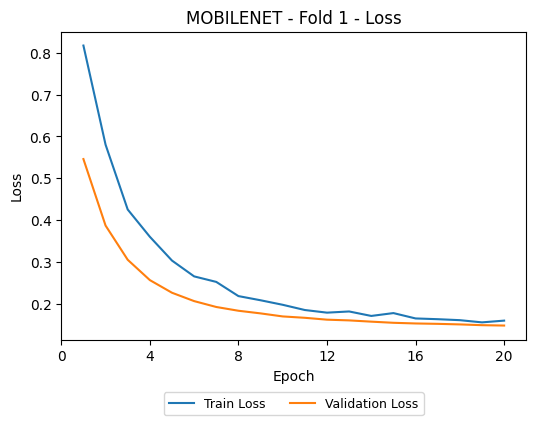

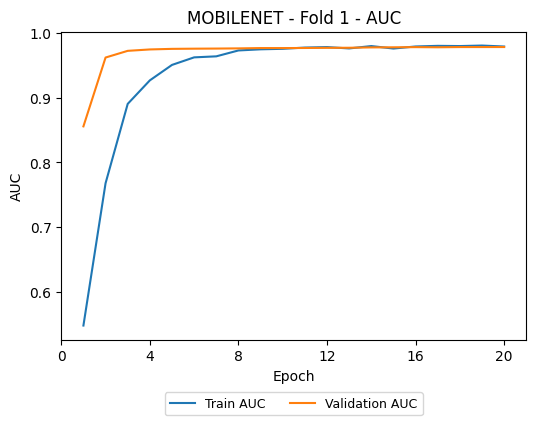

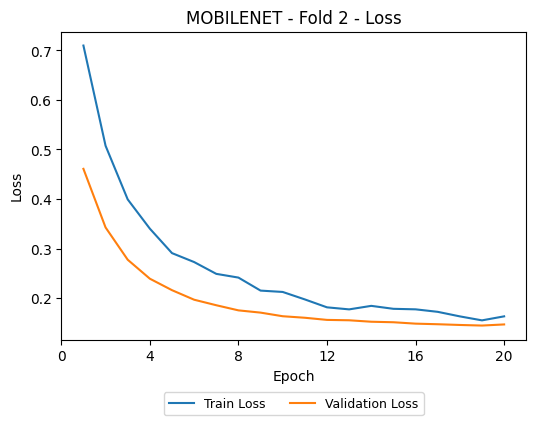

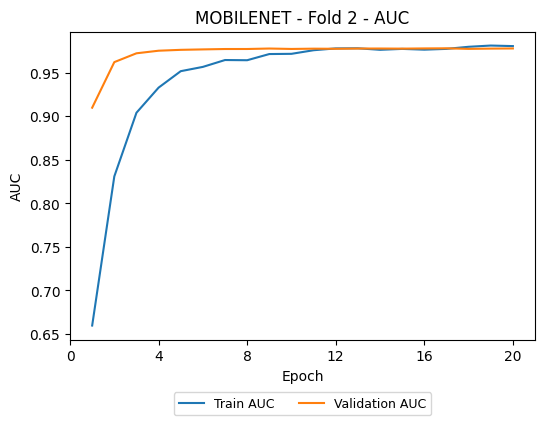

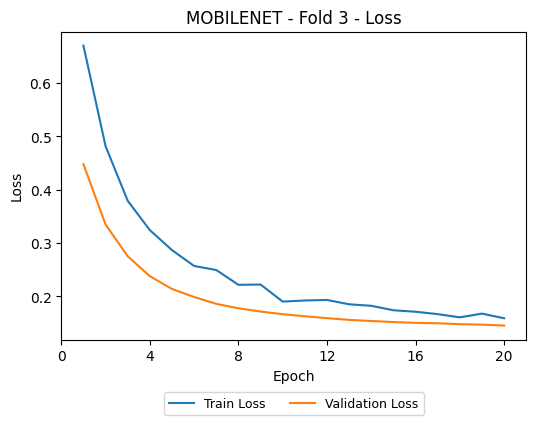

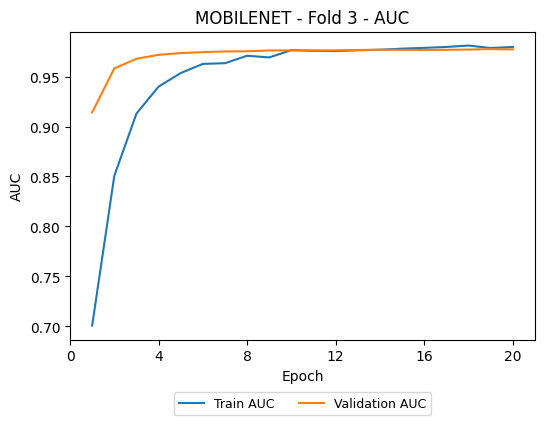

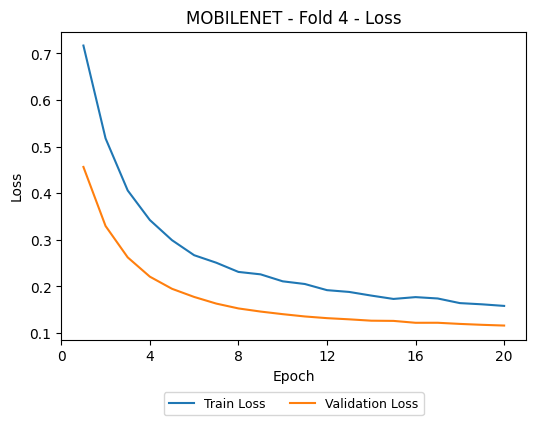

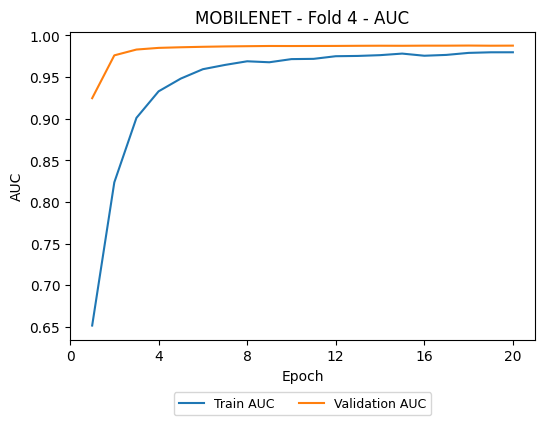

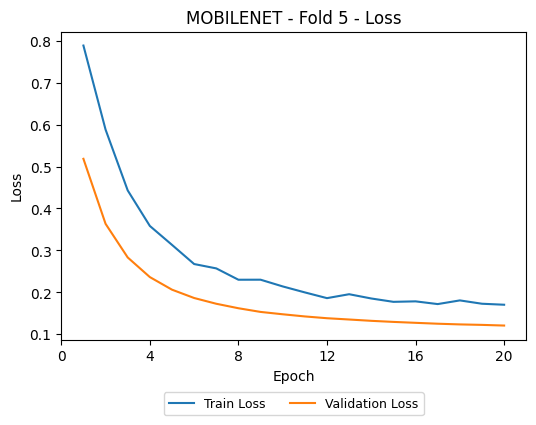

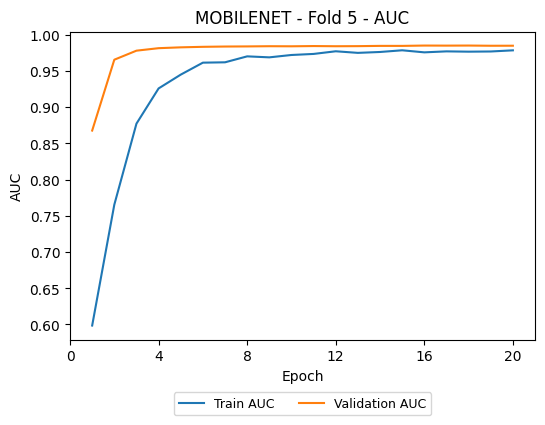

In [15]:
import matplotlib.pyplot as plt

# Nom du modèle
model_name = "mobilenet"

# Graduations voulues
xticks = [0, 4, 8, 12, 16, 20]

print(f"\n===== PLOTS FOR MODEL: {model_name.upper()} =====")

for fold_idx, history in enumerate(results["history"]):

    fold_num = fold_idx + 1
    epochs = range(1, len(history.get('loss', [])) + 1)

    # =====================
    # LOSS — 1 figure par fold
    # =====================
    plt.figure(figsize=(6,4))
    plt.plot(epochs, history.get('loss', []), label='Train Loss')
    plt.plot(epochs, history.get('val_loss', []), label='Validation Loss')

    plt.title(f'{model_name.upper()} - Fold {fold_num} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    plt.xlim(0, 21)
    plt.xticks(xticks)

    plt.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),
        ncol=3,
        fontsize=9
    )

    plt.show()

    # =====================
    # AUC — 1 figure par fold
    # =====================
    train_auc = history.get('AUC', history.get('auc', []))
    val_auc   = history.get('val_AUC', history.get('val_auc', []))

    plt.figure(figsize=(6,4))
    plt.plot(epochs, train_auc, label='Train AUC')
    plt.plot(epochs, val_auc, label='Validation AUC')

    plt.title(f'{model_name.upper()} - Fold {fold_num} - AUC')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')

    plt.xlim(0, 21)
    plt.xticks(xticks)

    plt.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),
        ncol=3,
        fontsize=9
    )

    plt.show()

In [14]:
import matplotlib.pyplot as plt
import numpy as np


for model_name in MODELS:

    # =========================
    # LOSS – tous les folds
    # =========================
    plt.figure(figsize=(8,6))
    
    for fold_idx, history in enumerate(results[model_name]["history"]):
        epochs = np.arange(1, len(history.get('loss', [])) + 1)

        plt.plot(
            epochs,
            history.get('loss', []),
            label=f'Train Fold {fold_idx+1}'
        )
        plt.plot(
            epochs,
            history.get('val_loss', []),
            linestyle='--',
            label=f'Val Fold {fold_idx+1}'
        )

    plt.title(f'{model_name.upper()} - Loss - tous les folds')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    # 🔹 ticks et limites
    plt.xticks([0, 4, 8, 12, 16, 20])
    plt.xlim(0.5, 20.5)

    #plt.legend()
    plt.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),
        ncol=5,
        fontsize=9
            )
    plt.show()

    # =========================
    # AUC – tous les folds
    # =========================
    plt.figure(figsize=(8,6))

    for fold_idx, history in enumerate(results[model_name]["history"]):
        train_auc = history.get('AUC', history.get('auc', []))
        val_auc   = history.get('val_AUC', history.get('val_auc', []))
        epochs = np.arange(1, len(train_auc) + 1)

        plt.plot(
            epochs,
            train_auc,
            label=f'Train Fold {fold_idx+1}'
        )
        plt.plot(
            epochs,
            val_auc,
            linestyle='--',
            label=f'Val Fold {fold_idx+1}'
        )

    plt.title(f'{model_name.upper()} - AUC - tous les folds')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')

    # 🔹 ticks et limites
    plt.xticks([0, 4, 8, 12, 16, 20])
    plt.xlim(0.5, 20.5)

    plt.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),
        ncol=5,
        fontsize=9
    )

    plt.show()


KeyError: 'mobilenet'

<Figure size 800x600 with 0 Axes>

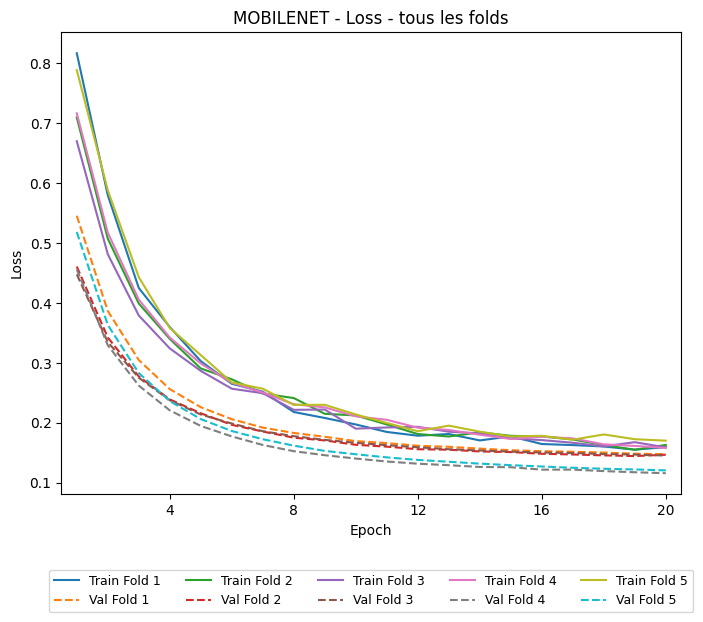

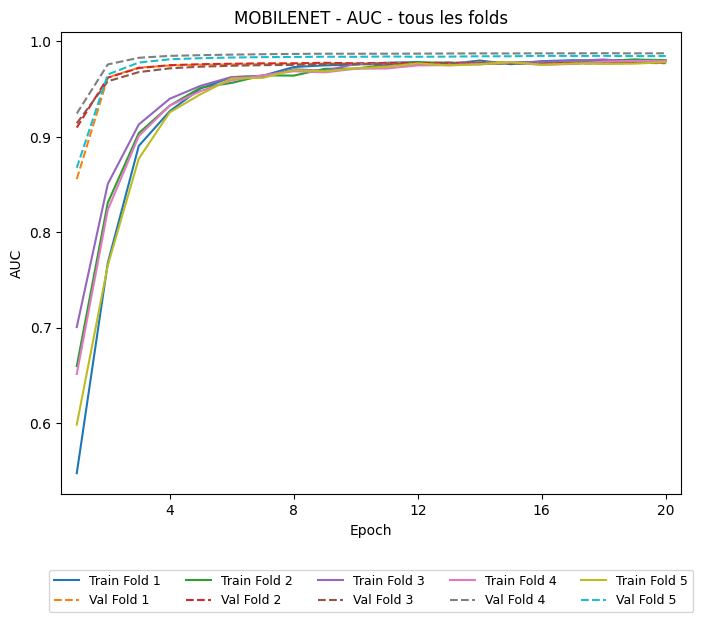

In [16]:
import matplotlib.pyplot as plt
import numpy as np

model_name = "mobilenet"

# =========================
# LOSS – tous les folds
# =========================
plt.figure(figsize=(8,6))

for fold_idx, history in enumerate(results["history"]):
    epochs = np.arange(1, len(history.get('loss', [])) + 1)

    plt.plot(
        epochs,
        history.get('loss', []),
        label=f'Train Fold {fold_idx+1}'
    )
    plt.plot(
        epochs,
        history.get('val_loss', []),
        linestyle='--',
        label=f'Val Fold {fold_idx+1}'
    )

plt.title(f'{model_name.upper()} - Loss - tous les folds')
plt.xlabel('Epoch')
plt.ylabel('Loss')

# 🔹 ticks et limites
plt.xticks([0, 4, 8, 12, 16, 20])
plt.xlim(0.5, 20.5)

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=5,
    fontsize=9
)
plt.show()


# =========================
# AUC – tous les folds
# =========================
plt.figure(figsize=(8,6))

for fold_idx, history in enumerate(results["history"]):
    train_auc = history.get('AUC', history.get('auc', []))
    val_auc   = history.get('val_AUC', history.get('val_auc', []))
    epochs = np.arange(1, len(train_auc) + 1)

    plt.plot(
        epochs,
        train_auc,
        label=f'Train Fold {fold_idx+1}'
    )
    plt.plot(
        epochs,
        val_auc,
        linestyle='--',
        label=f'Val Fold {fold_idx+1}'
    )

plt.title(f'{model_name.upper()} - AUC - tous les folds')
plt.xlabel('Epoch')
plt.ylabel('AUC')

# 🔹 ticks et limites
plt.xticks([0, 4, 8, 12, 16, 20])
plt.xlim(0.5, 20.5)

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=5,
    fontsize=9
)
plt.show()

## Visualtion selon la moyenne des métrique

In [17]:
import numpy as np
import matplotlib.pyplot as plt

for model_name in MODELS:

    histories = results[model_name]["history"]

    # =========================
    # Nombre max d'epochs
    # =========================
    max_epochs = max(len(h.get('loss', [])) for h in histories)
    epochs = np.arange(1, max_epochs + 1)

    # graduations personnalisées
    xticks = [0, 4, 8, 12, 16, 20]
    xticks = [x for x in xticks if x <= max_epochs]

    # =========================
    # ===== LOSS (tous les folds)
    # =========================
    plt.figure(figsize=(10, 5))

    all_train_loss, all_val_loss = [], []

    for history in histories:
        loss = history.get('loss', [])
        val_loss = history.get('val_loss', [])

        # Padding si arrêt anticipé
        if len(loss) < max_epochs:
            loss += [loss[-1]] * (max_epochs - len(loss))
            val_loss += [val_loss[-1]] * (max_epochs - len(val_loss))

        all_train_loss.append(loss)
        all_val_loss.append(val_loss)

        plt.plot(epochs, loss, color='blue', alpha=0.25)
        plt.plot(epochs, val_loss, color='orange', alpha=0.25)

    # Moyenne + écart-type
    train_mean = np.mean(all_train_loss, axis=0)
    train_std  = np.std(all_train_loss, axis=0)
    val_mean   = np.mean(all_val_loss, axis=0)
    val_std    = np.std(all_val_loss, axis=0)

    plt.plot(epochs, train_mean, color='blue', linewidth=2, label='Train Loss (moyenne)')
    plt.fill_between(epochs, train_mean-train_std, train_mean+train_std, color='blue', alpha=0.2)

    plt.plot(epochs, val_mean, color='orange', linewidth=2, label='Val Loss (moyenne)')
    plt.fill_between(epochs, val_mean-val_std, val_mean+val_std, color='orange', alpha=0.2)

    plt.title(f'{model_name.upper()} — Loss (tous les folds)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    # 👉 réglages axes
    plt.xlim(0, max_epochs + 0.5)
    plt.xticks(xticks)
    plt.margins(x=0.02, y=0.05)

    #plt.legend()
    plt.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.18),
        ncol=2,
        frameon=False
    )
    #plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # =========================
    # ===== AUC (tous les folds)
    # =========================
    plt.figure(figsize=(10, 5))

    all_train_auc, all_val_auc = [], []

    for history in histories:
        train_auc = history.get('AUC', history.get('auc', []))
        val_auc   = history.get('val_AUC', history.get('val_auc', []))

        if len(train_auc) < max_epochs:
            train_auc += [train_auc[-1]] * (max_epochs - len(train_auc))
            val_auc   += [val_auc[-1]] * (max_epochs - len(val_auc))

        all_train_auc.append(train_auc)
        all_val_auc.append(val_auc)

        plt.plot(epochs, train_auc, color='green', alpha=0.25)
        plt.plot(epochs, val_auc, color='red', alpha=0.25)

    train_mean = np.mean(all_train_auc, axis=0)
    train_std  = np.std(all_train_auc, axis=0)
    val_mean   = np.mean(all_val_auc, axis=0)
    val_std    = np.std(all_val_auc, axis=0)

    plt.plot(epochs, train_mean, color='green', linewidth=2, label='Train AUC (moyenne)')
    plt.fill_between(epochs, train_mean-train_std, train_mean+train_std, color='green', alpha=0.2)

    plt.plot(epochs, val_mean, color='red', linewidth=2, label='Val AUC (moyenne)')
    plt.fill_between(epochs, val_mean-val_std, val_mean+val_std, color='red', alpha=0.2)

    plt.title(f'{model_name.upper()} — AUC (tous les folds)')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')

    # 👉 réglages axes
    plt.xlim(0, max_epochs + 0.5)
    plt.xticks(xticks)
    plt.margins(x=0.02, y=0.05)

    # légende en bas
    plt.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.18),
        ncol=2,
        frameon=False
    )

    #plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


KeyError: 'mobilenet'

### Courbe de ROC des 3 modèles

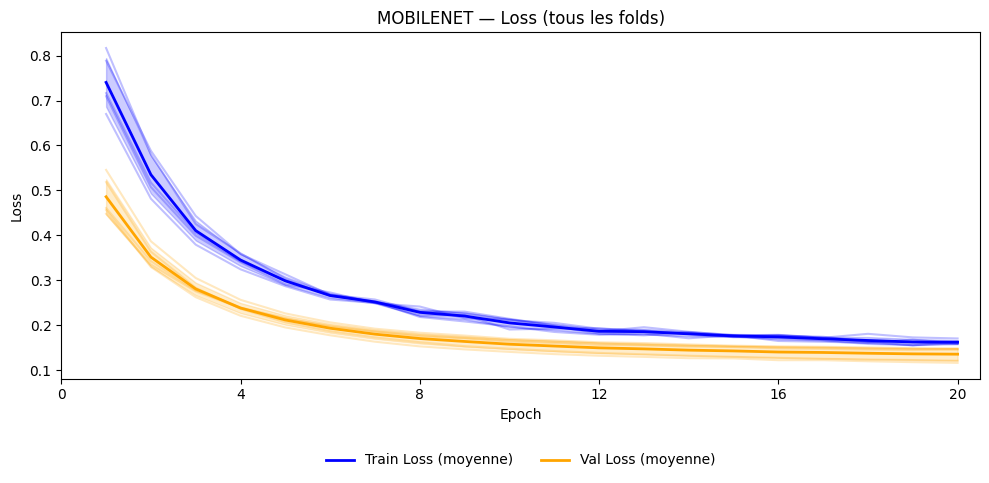

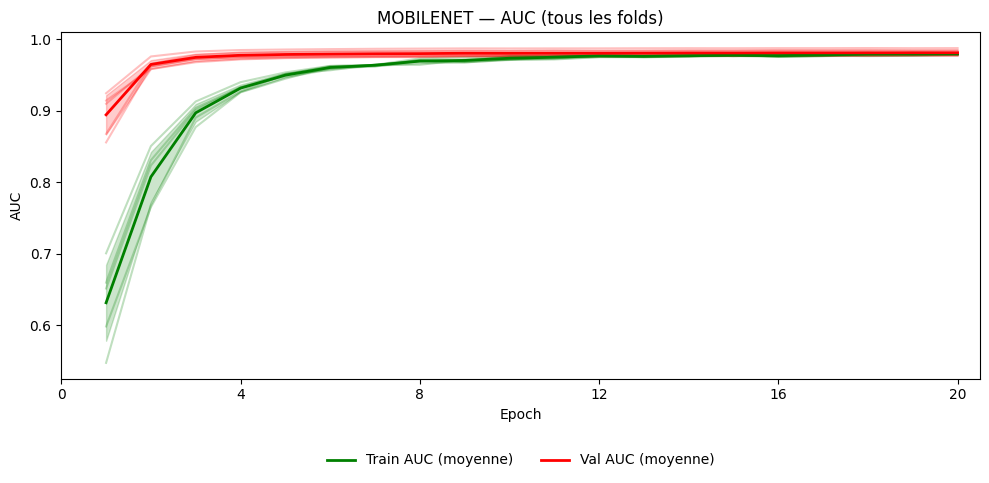

In [18]:
import numpy as np
import matplotlib.pyplot as plt

model_name = "mobilenet"
histories = results["history"]

# =========================
# Nombre max d'epochs
# =========================
max_epochs = max(len(h.get('loss', [])) for h in histories)
epochs = np.arange(1, max_epochs + 1)

# graduations personnalisées
xticks = [0, 4, 8, 12, 16, 20]
xticks = [x for x in xticks if x <= max_epochs]

# =========================
# LOSS (tous les folds)
# =========================
plt.figure(figsize=(10, 5))

all_train_loss, all_val_loss = [], []

for history in histories:
    loss = history.get('loss', [])
    val_loss = history.get('val_loss', [])

    # Padding si arrêt anticipé
    if len(loss) < max_epochs:
        loss += [loss[-1]] * (max_epochs - len(loss))
        val_loss += [val_loss[-1]] * (max_epochs - len(val_loss))

    all_train_loss.append(loss)
    all_val_loss.append(val_loss)

    plt.plot(epochs, loss, color='blue', alpha=0.25)
    plt.plot(epochs, val_loss, color='orange', alpha=0.25)

# Moyenne ± écart-type
train_mean = np.mean(all_train_loss, axis=0)
train_std  = np.std(all_train_loss, axis=0)
val_mean   = np.mean(all_val_loss, axis=0)
val_std    = np.std(all_val_loss, axis=0)

plt.plot(epochs, train_mean, color='blue', linewidth=2, label='Train Loss (moyenne)')
plt.fill_between(epochs, train_mean-train_std, train_mean+train_std, color='blue', alpha=0.2)

plt.plot(epochs, val_mean, color='orange', linewidth=2, label='Val Loss (moyenne)')
plt.fill_between(epochs, val_mean-val_std, val_mean+val_std, color='orange', alpha=0.2)

plt.title(f'{model_name.upper()} — Loss (tous les folds)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xlim(0, max_epochs + 0.5)
plt.xticks(xticks)
plt.margins(x=0.02, y=0.05)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

# =========================
# AUC (tous les folds)
# =========================
plt.figure(figsize=(10, 5))

all_train_auc, all_val_auc = [], []

for history in histories:
    train_auc = history.get('AUC', history.get('auc', []))
    val_auc   = history.get('val_AUC', history.get('val_auc', []))

    # Padding si arrêt anticipé
    if len(train_auc) < max_epochs:
        train_auc += [train_auc[-1]] * (max_epochs - len(train_auc))
        val_auc   += [val_auc[-1]] * (max_epochs - len(val_auc))

    all_train_auc.append(train_auc)
    all_val_auc.append(val_auc)

    plt.plot(epochs, train_auc, color='green', alpha=0.25)
    plt.plot(epochs, val_auc, color='red', alpha=0.25)

# Moyenne ± écart-type
train_mean = np.mean(all_train_auc, axis=0)
train_std  = np.std(all_train_auc, axis=0)
val_mean   = np.mean(all_val_auc, axis=0)
val_std    = np.std(all_val_auc, axis=0)

plt.plot(epochs, train_mean, color='green', linewidth=2, label='Train AUC (moyenne)')
plt.fill_between(epochs, train_mean-train_std, train_mean+train_std, color='green', alpha=0.2)

plt.plot(epochs, val_mean, color='red', linewidth=2, label='Val AUC (moyenne)')
plt.fill_between(epochs, val_mean-val_std, val_mean+val_std, color='red', alpha=0.2)

plt.title(f'{model_name.upper()} — AUC (tous les folds)')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.xlim(0, max_epochs + 0.5)
plt.xticks(xticks)
plt.margins(x=0.02, y=0.05)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

plt.figure(figsize=(10,8))

for model_name, data in results.items():
    if "efficientnet" in model_name:  # <-- ignore EfficientNet
        continue

    # Stocker les courbes ROC de tous les folds
    tprs = []
    base_fpr = np.linspace(0, 1, 101)  # points communs pour interpolation

    for y_true, y_prob in zip(data["y_true"], data["y_prob"]):
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        tpr_interp = np.interp(base_fpr, fpr, tpr)
        tpr_interp[0] = 0.0
        tprs.append(tpr_interp)

    # Moyenne des TPRs pour la courbe ROC moyenne
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(base_fpr, mean_tpr)

    plt.plot(base_fpr, mean_tpr, lw=2, label=f'{model_name}')

plt.plot([0,1], [0,1], linestyle='--', color='gray')  # ligne diagonale hasard
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
#plt.title('Courbes ROC des modèles')
plt.legend(loc='lower right')
plt.show()


TypeError: list indices must be integers or slices, not str

<Figure size 1000x800 with 0 Axes>

## Comparaison des moèle avec les métriques

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score

# Liste pour stocker les lignes du tableau
summary = []

for model_name, data in results.items():
    # Calculer l’accuracy globale par fold
    acc_list = [np.mean((y_prob>0.5).astype(int)==y_true) for y_true, y_prob in zip(data["y_true"], data["y_prob"])]
    auc_list = data["auc"]

    # Calculer les métriques par classe pour chaque fold
    class_metrics = {"0": {"precision": [], "recall": [], "f1-score": []},
                     "1": {"precision": [], "recall": [], "f1-score": []}}

    for y_true, y_prob in zip(data["y_true"], data["y_prob"]):
        y_pred = (y_prob > 0.5).astype(int)
        report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
        for cls in ["0", "1"]:
            class_metrics[cls]["precision"].append(report[cls]["precision"])
            class_metrics[cls]["recall"].append(report[cls]["recall"])
            class_metrics[cls]["f1-score"].append(report[cls]["f1-score"])

    # Ajouter une ligne pour Cancer-
    summary.append({
        "Modèle": model_name,
        "Cancer": "Cancer-",
        "Accuracy": round(np.mean(acc_list),3),
        "Précision": round(np.mean(class_metrics["0"]["precision"]),3),
        "Sensibilité": round(np.mean(class_metrics["0"]["recall"]),3),
        "F1-score": round(np.mean(class_metrics["0"]["f1-score"]),3),
        "AUC": round(np.mean(auc_list),3)
    })

    # Ajouter une ligne pour Cancer+
    summary.append({
        "Modèle": model_name,
        "Cancer": "Cancer+",
        "Accuracy": round(np.mean(acc_list),3),
        "Précision": round(np.mean(class_metrics["1"]["precision"]),3),
        "Sensibilité": round(np.mean(class_metrics["1"]["recall"]),3),
        "F1-score": round(np.mean(class_metrics["1"]["f1-score"]),3),
        "AUC": round(np.mean(auc_list),3)
    })

# Créer le DataFrame
df_summary = pd.DataFrame(summary)

# Afficher toutes les colonnes
pd.set_option("display.max_columns", None)
print(df_summary)


         Modèle   Cancer  Accuracy  Précision  Sensibilité  F1-score    AUC
0      resnet50  Cancer-     0.697      0.735        0.657     0.677  0.782
1      resnet50  Cancer+     0.697      0.700        0.736     0.701  0.782
2         vgg19  Cancer-     0.809      0.765        0.894     0.824  0.899
3         vgg19  Cancer+     0.809      0.872        0.724     0.791  0.899
4  efficientnet  Cancer-     0.500      0.100        0.200     0.133  0.619
5  efficientnet  Cancer+     0.500      0.400        0.800     0.533  0.619
6      densenet  Cancer-     0.901      0.863        0.955     0.906  0.960
7      densenet  Cancer+     0.901      0.949        0.847     0.895  0.960
8     mobilenet  Cancer-     0.966      0.951        0.983     0.967  0.980
9     mobilenet  Cancer+     0.966      0.982        0.949     0.965  0.980


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

# ===============================
# AGRÉGATION DES RÉSULTATS
# ===============================

summary = []

for model_name, data in results.items():

    # Accuracy par fold
    acc_list = [
        np.mean((y_prob > 0.5).astype(int) == y_true)
        for y_true, y_prob in zip(data["y_true"], data["y_prob"])
    ]

    # AUC par fold (déjà calculée)
    auc_list = data["auc"]

    # Métriques par classe et par fold
    class_metrics = {
        "0": {"precision": [], "recall": [], "f1-score": []},
        "1": {"precision": [], "recall": [], "f1-score": []}
    }

    for y_true, y_prob in zip(data["y_true"], data["y_prob"]):
        y_pred = (y_prob > 0.5).astype(int)

        report = classification_report(
            y_true, y_pred,
            output_dict=True,
            zero_division=0
        )

        for cls in ["0", "1"]:
            class_metrics[cls]["precision"].append(report[cls]["precision"])
            class_metrics[cls]["recall"].append(report[cls]["recall"])
            class_metrics[cls]["f1-score"].append(report[cls]["f1-score"])

    # ---------- Cancer -
    summary.append({
        "Modèle": model_name,
        "Classe": "Cancer-",
        "Accuracy": round(np.mean(acc_list), 3),
        "Précision": round(np.mean(class_metrics["0"]["precision"]), 3),
        "Sensibilité": round(np.mean(class_metrics["0"]["recall"]), 3),
        "F1-score": round(np.mean(class_metrics["0"]["f1-score"]), 3),
        "AUC": round(np.mean(auc_list), 3)
    })

    # ---------- Cancer +
    summary.append({
        "Modèle": model_name,
        "Classe": "Cancer+",
        "Accuracy": round(np.mean(acc_list), 3),
        "Précision": round(np.mean(class_metrics["1"]["precision"]), 3),
        "Sensibilité": round(np.mean(class_metrics["1"]["recall"]), 3),
        "F1-score": round(np.mean(class_metrics["1"]["f1-score"]), 3),
        "AUC": round(np.mean(auc_list), 3)
    })


# ===============================
# CRÉATION DU DATAFRAME
# ===============================

df_summary = pd.DataFrame(summary)

pd.set_option("display.max_columns", None)
print(df_summary)


# ===============================
# EXPORT EXCEL (.XLS) SANS MODULE
# ===============================

output_file = "resultats_models_mammographie.xls"

html_string = df_summary.to_html(index=False)

with open(output_file, "w", encoding="utf-8") as f:
    f.write(html_string)

print(f"\n✅ Résultats exportés avec succès (Excel .xls) : {output_file}")



         Modèle   Classe  Accuracy  Précision  Sensibilité  F1-score    AUC
0      resnet50  Cancer-     0.697      0.735        0.657     0.677  0.782
1      resnet50  Cancer+     0.697      0.700        0.736     0.701  0.782
2         vgg19  Cancer-     0.809      0.765        0.894     0.824  0.899
3         vgg19  Cancer+     0.809      0.872        0.724     0.791  0.899
4  efficientnet  Cancer-     0.500      0.100        0.200     0.133  0.619
5  efficientnet  Cancer+     0.500      0.400        0.800     0.533  0.619
6      densenet  Cancer-     0.901      0.863        0.955     0.906  0.960
7      densenet  Cancer+     0.901      0.949        0.847     0.895  0.960
8     mobilenet  Cancer-     0.966      0.951        0.983     0.967  0.980
9     mobilenet  Cancer+     0.966      0.982        0.949     0.965  0.980

✅ Résultats exportés avec succès (Excel .xls) : resultats_models_mammographie.xls
